# Embedding multimodal data for similarity search using transformers, datasets and FAISS

Embeddings represent a fundamental paradigm in modern machine learning, providing semantically meaningful dimensionality reduction that preserves crucial relational properties within high-dimensional data spaces. Formally, high-dimensional inputs to dense vector representations where semantic similarity correlates with geometric proximity.

Research Problem: This notebook addresses the challenge of cross-modal information retrieval in agricultural applications, specifically leveraging multimodal representation learning to enable semantic similarity search across textual disease descriptions and visual plant pathology imagery.

Methodological Approach: We implement a transformer-based multimodal architecture combining:
- CLIP (Contrastive Language-Image Pre-training) for joint vision-language representation learning
- FAISS (Facebook AI Similarity Search) for efficient approximate nearest neighbor search
- HuggingFace Datasets ecosystem for scalable data processing and index management

Let's install the necessary dependencies.

In [ ]:
!pip install dill>=0.3.9 dill>=0.3.9
!pip install torchvision 
!pip install -q datasets faiss-gpu transformers sentencepiece

We employ the [CLIP model](https://huggingface.co/openai/clip-vit-base-patch16) for multimodal feature extraction, specifically the Vision Transformer Base variant with 16x16 patch tokenization. CLIP represents a paradigm shift from supervised learning to contrastive multimodal pre-training, enabling zero-shot transfer learning capabilities essential for agricultural applications with limited labeled data.

In [2]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer
import faiss
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

model = AutoModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
processor = AutoImageProcessor.from_pretrained("openai/clip-vit-base-patch16")
tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch16")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


We utilize the lorenzoxi/tomato-leaves-dataset, comprising 14,404 high-resolution tomato leaf images across 8 taxonomically distinct disease categories. This dataset represents a statistically significant sample of Solanum lycopersicum pathologies commonly encountered in commercial agricultural production.

This dataset choice optimizes the balance between computational tractability and agricultural relevance for proof-of-concept implementation.

In [ ]:
from datasets import load_dataset

ds = load_dataset("lorenzoxi/tomato-leaves-dataset")

Resolving data files:   0%|          | 0/14404 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1796 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1796 [00:00<?, ?it/s]

image%20%281064%29.JPG:   0%|          | 0.00/26.0k [00:00<?, ?B/s]

image%20%284766%29.JPG:   0%|          | 0.00/9.54k [00:00<?, ?B/s]

...

image%20%28775%29.JPG:   0%|          | 0.00/18.3k [00:00<?, ?B/s]

image%20%28981%29.JPG:   0%|          | 0.00/27.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14404 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1796 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1796 [00:00<?, ? examples/s]

See an example.

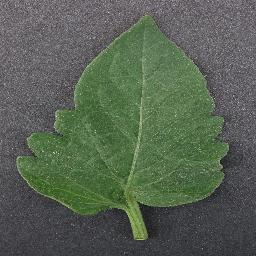

In [22]:
ds["train"][14000]["image"]

In [23]:
ds["train"][14000]['label']

7

We don't have to write any function to embed examples or create an index. datasets library's FAISS integration abstracts these processes. We can simply use `map` method of the dataset to create a new column with the embeddings for each example like below. Let's create one for text features on the prompt column.

In [25]:
dataset = ds["train"]
ds_with_embeddings = dataset.map(lambda example:
                                {'embeddings': model.get_text_features(
                                    **tokenizer([str(example["label"])],
                                                truncation=True, return_tensors="pt")
                                    .to("cuda"))[0].detach().cpu().numpy()})


Map:   0%|          | 0/14404 [00:00<?, ? examples/s]

We can do the same and get the image embeddings.

In [26]:
ds_with_embeddings = ds_with_embeddings.map(lambda example:
                                          {'image_embeddings': model.get_image_features(
                                              **processor([example["image"]], return_tensors="pt")
                                              .to("cuda"))[0].detach().cpu().numpy()})


Map:   0%|          | 0/14404 [00:00<?, ? examples/s]

Now, we create an index for each column.

In [27]:
# create FAISS index for text embeddings
ds_with_embeddings.add_faiss_index(column='embeddings')

  0%|          | 0/15 [00:00<?, ?it/s]

Dataset({
    features: ['image', 'label', 'embeddings', 'image_embeddings'],
    num_rows: 14404
})

In [28]:
# create FAISS index for image embeddings
ds_with_embeddings.add_faiss_index(column='image_embeddings')

  0%|          | 0/15 [00:00<?, ?it/s]

Dataset({
    features: ['image', 'label', 'embeddings', 'image_embeddings'],
    num_rows: 14404
})

## Querying the data with image prompts

Image similarity inference is similar, where you just call `get_image_features`.

In [29]:
def downscale_images(image):
  width = 200
  ratio = (width / float(image.size[0]))
  height = int((float(image.size[1]) * float(ratio)))
  img = image.resize((width, height), Image.Resampling.LANCZOS)
  return img

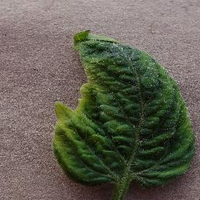

In [37]:
import requests
# image of a beaver
url = "https://datasets-server.huggingface.co/cached-assets/yusuf802/leaf-images/--/21a4c1f7ca0e538f4bf2be0aa92e385d7cd041c0/--/default/train/33/image/image.jpg?Expires=1742397789&Signature=u-BwDD5wYRgMWaqhHhB~TlaTKtd4-MYgGSKJhYnQ0DxofiKNMx-5oY7UOOHK6wfypKQIGgXp6dTrD2D2uvuJbDYGfLjCHvB3weLHsyiNaL5g1V4odZbNh3r0ly1hDm6fOR0Ao768kHdVDCsSFrm4QDkIwPIZhjwWd7rFjQbOfM0lzPghrQ49RV5~NCLL9HTDbPlQGtri0HIPBuuGZdsy2yVIed5hJyX~eRhJ1JZIdBs6ajlFbQy0OwCx9LEUqX82ndPYSq2W53fEcVZE7Y7guP-Enty8Wv1yJKWgb3cUNR3wgAEB19icHQRBpt6xHX1QaNLmTudZhkVQz1z0ZTe~jg__&Key-Pair-Id=K3EI6M078Z3AC3"
image = Image.open(requests.get(url, stream=True).raw)
display(downscale_images(image))

Search for the similar image.

In [38]:
img_embedding = model.get_image_features(**processor([image], return_tensors="pt", truncation=True).to("cuda"))[0].detach().cpu().numpy()
scores, retrieved_examples = ds_with_embeddings.get_nearest_examples('image_embeddings', img_embedding, k=1)

Unused or unrecognized kwargs: truncation.


Display the most similar image to the beaver image.

[5]


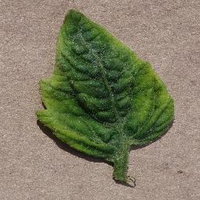

In [39]:
images = [downscale_images(image) for image in retrieved_examples["image"]]
# see the closest text and image
print(retrieved_examples["label"])
display(images[0])

## Saving, pushing and loading the embeddings
We can save the dataset with embeddings with `save_faiss_index`.


In [40]:
ds_with_embeddings.save_faiss_index('embeddings', 'index/embeddings.faiss')

In [41]:
ds_with_embeddings.save_faiss_index('image_embeddings', 'index/image_embeddings.faiss')

In [42]:
ds_with_embeddings.drop_index("embeddings")
ds_with_embeddings.drop_index("image_embeddings")

In [43]:
# save to disk index
# ds_with_embeddings.save_to_disk('index')

# save to disk dataset
dataset.save_to_disk('dataset')

Saving the dataset (0/1 shards):   0%|          | 0/14404 [00:00<?, ? examples/s]

In [44]:
# save to s3
import sagemaker

bucket = "programboy-cm3070-foobarfoobarfoobarml"
sess = sagemaker.Session(default_bucket=bucket)

ds_embeddings_uri = sess.upload_data(path='./dataset', bucket=sess.default_bucket(), key_prefix='dataset')
print(ds_embeddings_uri)

embeddings_uri = sess.upload_data(path='./index', bucket=sess.default_bucket(), key_prefix='index')
print(embeddings_uri)

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[03/19/25 14:25:27] INFO     Found credentials from IAM Role:                                   ]8;id=10289;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=976353;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


[03/19/25 14:25:30] INFO     Found credentials from IAM Role:                                   ]8;id=208133;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=639361;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

s3://programboy-cm3070-foobarfoobarfoobarml/dataset
s3://programboy-cm3070-foobarfoobarfoobarml/index
